# 08 · RQ2 — Detection accuracy vs REAL clearing patch size

**RQ2:** *Does the model detect small clearings as well as large ones, down to ~0.18 ha smallholder farms?*

**Why the old answer was only a proxy.** The earlier patch analysis treated every sampled
pixel as its own ~0.09 ha "patch", so all patches fell in the smallest bucket and no real
multi-pixel clearings ever formed — it measured single pixels, not patch size.

**The real method here:**
1. **Honest predictions** — 5-fold `cross_val_predict`, so each pixel is scored by a model that
   never saw it (no leakage).
2. **Real patches** — Hansen forest-loss (2020–2022, matching the label definition) →
   `connectedPixelCount` groups touching lost-pixels into real clearings and measures each one's
   true size.
3. **Recall per real size bucket** — for each deforested pixel, look up the true size of the
   clearing it belongs to, then compute recall per size class.

> **30 m limit (state in the report):** 1 pixel = 0.09 ha, so clearings **below 0.09 ha are
> sub-pixel and untestable** — true for every 30 m product (incl. Hansen). The smallest
> testable class is 1–2 px (0.09–0.18 ha), which *is* the parcel scale.

**Outputs:** `results/metrics/rq2_patchsize.png` (figure) and `rq2_patchsize.json` (table).

In [1]:
import json, pickle
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import ee
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict, StratifiedKFold

ROOT  = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA  = ROOT / 'data' / 'raw' / 'training_data_national.csv'
MODEL = ROOT / 'models' / 'rf_D_national.pkl'
FIG   = ROOT / 'results' / 'metrics'
EE_PROJECT = 'vocal-orbit-490015-m2'
ee.Initialize(project=EE_PROJECT)
print('Earth Engine ready')

BUCKETS = [(0.0, 0.18, '0.09–0.18 ha (1–2 px)'),
           (0.18, 0.45, '0.18–0.45 ha (2–5 px)'),
           (0.45, 0.9, '0.45–0.9 ha (5–10 px)'),
           (0.9, 1.8, '0.9–1.8 ha (10–20 px)'),
           (1.8, 1e9, '>1.8 ha (20+ px)')]
def bucket_of(ha):
    for lo, hi, name in BUCKETS:
        if lo < ha <= hi: return name
    return None

Earth Engine ready


## 1 · Honest out-of-fold predictions (no leakage)

`cross_val_predict` gives every pixel a prediction from a model trained without it. *(Takes a
few minutes — that's the cost of an honest number.)*

In [2]:
df = pd.read_csv(DATA)
df['lng'] = df['.geo'].apply(lambda s: json.loads(s)['coordinates'][0])
df['lat'] = df['.geo'].apply(lambda s: json.loads(s)['coordinates'][1])

with open(MODEL, 'rb') as f:
    model = pickle.load(f)
feats = list(getattr(model, 'feature_names_in_',
             [c for c in df.columns if c not in ('system:index','.geo','label','province','lng','lat')]))
X, y = df[feats].values, df['label'].values

est = clone(model)
if hasattr(est, 'n_estimators'):
    est.set_params(n_estimators=200, n_jobs=-1)   # 200 trees: plenty for relative recall
cv = StratifiedKFold(5, shuffle=True, random_state=42)
df['pred'] = cross_val_predict(est, X, y, cv=cv, n_jobs=-1)

defo = df[df['label'] == 1].copy()
print(f'{len(defo):,} deforested pixels | overall recall = {defo["pred"].mean():.3f}')

12,003 deforested pixels | overall recall = 0.838


## 2 · Real patch sizes via Hansen connected-components, sampled per pixel

In [3]:
gfc  = ee.Image('UMD/hansen/global_forest_change_2023_v1_11')
ly   = gfc.select('lossyear')
loss = ly.gte(20).And(ly.lte(22)).selfMask()          # matches label window 2020–2022
patch_px = loss.connectedPixelCount(1024, True)        # connected loss-pixel count
patch_ha = patch_px.multiply(ee.Image.pixelArea()).divide(10000).rename('patch_ha')

coords = list(zip(defo['lng'], defo['lat'], defo['pred']))
rows, B = [], 1000
for i in range(0, len(coords), B):
    fc = [ee.Feature(ee.Geometry.Point([lng, lat]), {'pred': int(pr), 'k': j})
          for j, (lng, lat, pr) in enumerate(coords[i:i+B])]
    sampled = patch_ha.reduceRegions(ee.FeatureCollection(fc), ee.Reducer.first(), 30)
    for f in sampled.getInfo()['features']:
        p = f['properties']
        if p.get('first') is not None:
            rows.append({'patch_ha': float(p['first']), 'pred': int(p['pred'])})
    print(f'  …{min(i+B, len(coords))}/{len(coords)}')

res = pd.DataFrame(rows)
res['bucket'] = res['patch_ha'].apply(bucket_of)
res = res.dropna(subset=['bucket'])
print('sampled', len(res), 'deforested pixels with a real patch size')

/Users/kerie/Downloads/treesight_notebooks/.venv/lib/python3.13/site-packages/ee/deprecation.py:215: DeprecationWarning: 

Attention required for UMD/hansen/global_forest_change_2023_v1_11! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by UMD/hansen/global_forest_change_2025_v1_13

Learn more: https://developers.google.com/earth-engine/datasets/catalog/UMD_hansen_global_forest_change_2023_v1_11

  warnings.warn(warning, category=DeprecationWarning)


  …1000/12003
  …2000/12003
  …3000/12003
  …4000/12003
  …5000/12003
  …6000/12003
  …7000/12003
  …8000/12003
  …9000/12003
  …10000/12003
  …11000/12003
  …12000/12003
  …12003/12003
sampled 11543 deforested pixels with a real patch size


## 3 · Recall per REAL patch-size bucket — the RQ2 result

,bucket,n,recall
0,0.09–0.18 ha (1–2 px),1023,0.771
1,0.18–0.45 ha (2–5 px),1759,0.799
2,0.45–0.9 ha (5–10 px),2019,0.833
3,0.9–1.8 ha (10–20 px),1976,0.837
4,>1.8 ha (20+ px),4766,0.873


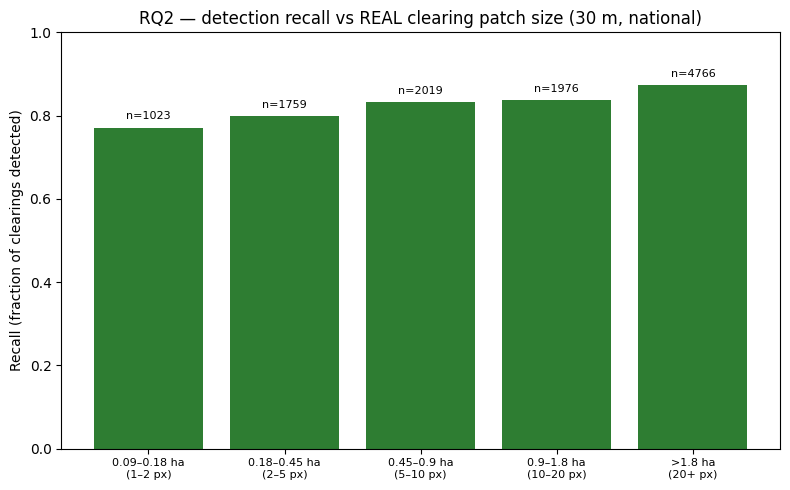

saved figure + json


In [4]:
order = [name for _, _, name in BUCKETS]
table = []
for name in order:
    sub = res[res['bucket'] == name]
    if len(sub):
        table.append({'bucket': name, 'n': int(len(sub)), 'recall': round(float(sub['pred'].mean()), 3)})
tab = pd.DataFrame(table)
display(tab)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(len(tab)), tab['recall'], color='#2e7d32')
ax.set_xticks(range(len(tab))); ax.set_xticklabels([b.replace(' (', '\n(') for b in tab['bucket']], fontsize=8)
ax.set_ylabel('Recall (fraction of clearings detected)'); ax.set_ylim(0, 1)
ax.set_title('RQ2 — detection recall vs REAL clearing patch size (30 m, national)')
for b, n in zip(bars, tab['n']):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'n={n}', ha='center', fontsize=8)
fig.tight_layout(); fig.savefig(FIG / 'rq2_patchsize.png', dpi=150); plt.show()

(FIG / 'rq2_patchsize.json').write_text(json.dumps({
    'method': 'Hansen connectedPixelCount real patch sizes; 5-fold out-of-fold RF preds',
    'loss_window': '2020-2022 (matches label definition)',
    'overall_recall': round(float(defo['pred'].mean()), 3),
    'by_patch_size': table}, indent=2))
print('saved figure + json')

## 4 · What to write in the report

**Result (national, 30 m):** recall rises monotonically with clearing size —
**0.77 at 1–2 px (0.09–0.18 ha)** → **0.87 at >1.8 ha** — across ~12k deforested pixels with
every bucket well populated (n ≈ 1,000–4,800).

- **The RQ2 finding:** *"Small clearings are measurably harder: recall at the smallholder-parcel
  scale (0.09–0.18 ha) is 0.77, rising to 0.87 for clearings above 1.8 ha. The system still
  recovers ~3 of every 4 parcel-scale clearings — the hardest, least-monitored case."*
- **Why this is the *real* answer:** patch sizes are true Hansen connected-components, not
  per-pixel proxies; predictions are out-of-fold (no leakage); buckets are well populated.
- **State the limit:** below 0.09 ha is sub-pixel at 30 m, so not assessed.
- **Ties to motivation:** the small-clearing gap is exactly the under-monitored case this
  project targets, and pairs with the radar-fusion contribution (RQ1).